In [1]:
%matplotlib qt

In [2]:
# from turtle import pos

import matplotlib

# matplotlib.use("Agg")  # for mac users

#print(matplotlib.get_backend())

import sys

import matplotlib as mpl

sys.path.append("/home/weipeng/CODES/Smilei")
import happi
import matplotlib.pyplot as plt
import numpy as np

jetcmap = plt.cm.get_cmap(
    "jet", 9
)  # generate a jet map with 10 values "rainbow", "jet", YlOrRd
jet_vals = jetcmap(np.arange(9))  # extract those values as an array
jet_vals[0] = [1.0, 1, 1.0, 1]  # change the first value
jet_vals[8] = [0.0, 0, 0.0, 1]  # change the first value
newcmap = mpl.colors.LinearSegmentedColormap.from_list("mine", jet_vals)

from matplotlib import font_manager

font_dirs = ["/Users/yao/Documents/Calibri and Cambria Fonts/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
   font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams["font.family"] = "Calibri"

plt.rc("text", usetex=False)
plt.rc("xtick", labelsize=14)
plt.rc("ytick", labelsize=14)
plt.rc("axes", labelsize=14)
plt.rc("legend", fontsize=12)

import scienceplots as splt

plt.style.use(["nature", "notebook", "grid", "high-vis"])

/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_26002/4764761.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jetcmap = plt.cm.get_cmap(


In [3]:
wkdir = [
        "/Users/yao/Documents/Data/IFE/ife_004_a0300_ne60_res80_ppc4/",
        "/Users/yao/Documents/Data/IFE/ife_003_a0400_ne60_res80_ppc4/",
        "/Users/yao/Documents/Data/IFE/ife_001_a0500_ne60_res80_ppc4/",
        "/Users/yao/Documents/Data/IFE/ife_002_a0600_ne60_res80_ppc4/",
]

S0 = happi.Open(
    wkdir[0], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
S1 = happi.Open(
    wkdir[1], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
S2 = happi.Open(
    wkdir[2], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
S3 = happi.Open(
    wkdir[3], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
# S4 = happi.Open(
#     wkdir[4], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S5 = happi.Open(
#     wkdir[5], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S6 = happi.Open(
#     wkdir[6], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S7 = happi.Open(
#     wkdir[7], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S8 = happi.Open(
#     wkdir[8], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )

# Get simulation box size
Lx = S0.namelist.Lx / 2 / np.pi  # in um
print("Lx = ", Lx)
Ly = S0.namelist.Ly / 2 / np.pi  # in um
print("Ly = ", Ly)
Lz = S0.namelist.Lz / 2 / np.pi  # in um
print("Lz = ", Lz)

Loaded simulation '/Users/yao/Documents/Data/IFE/ife_004_a0300_ne60_res80_ppc4/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/IFE/ife_003_a0400_ne60_res80_ppc4/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/IFE/ife_001_a0500_ne60_res80_ppc4/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning 

In [ ]:
## our former way to get the Bx-a0 scaling data using the FFT filter but picking only one point from the lineout, which is not very robust. 
# We will switch to a more robust way by averaging over a small region and a few time snapshot and also providing error bars for the data points.

def get_fft(S, time, vmin0, vmax0):
    Bx = S.Probe(0, "Bx", units=["um", "fs", "1e5 T"])
    data = np.array(Bx.getData()[time])
    field_x = np.array(Bx.getAxis("axis1"))
    field_y = np.array(Bx.getAxis("axis2"))
    print("time = ", Bx.getTimes()[time], " fs")

    plt.figure(figsize=(6, 5))
    plt.imshow(
        data.T,
        extent=(field_x.min(), field_x.max(), field_y.min(), field_y.max()),
        origin="lower",
        cmap="bwr",
        aspect="auto",
        vmin=vmin0,
        vmax=vmax0,
    )
    plt.colorbar()
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.title("Bx field in real space (before FFT)")
    plt.tight_layout()
    plt.savefig(wkdir[0]+"data_before_FFT"+str(time)+".png", dpi=300)
    # plt.show()
    plt.close()   

    Nx = data.shape[0]
    Ny = data.shape[1]
    dx = (field_x[1] - field_x[0])[0]
    dy = (field_y[1] - field_y[0])[1]
    kx = np.fft.fftfreq(Nx, d=dx)  # / (2 * np.pi)  # spatial freq extents
    ky = np.fft.fftfreq(Ny, d=dy)  # / (2 * np.pi)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    data_fft = np.fft.fft2(data, axes=(0, 1))  # shape (Nx, Ny)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     np.log10(np.abs(data_fft).T),
    #     extent=(kx.min(), kx.max(), ky.min(), ky.max()),
    #     origin="lower",
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Fourier Transform of Bx in log10 scale")
    # plt.tight_layout()
    # plt.show()

    data_fft_shift = np.fft.fftshift(data_fft)
    kx_shift = np.fft.fftshift(kx)
    ky_shift = np.fft.fftshift(ky)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     np.log10(np.abs(data_fft_shift).T),
    #     extent=(kx_shift.min(), kx_shift.max(), ky_shift.min(), ky_shift.max()),
    #     origin="lower",
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Shifted (& Zoom) Fourier Transform of Bx in log10 scale")
    # plt.xlim(-2, 2)
    # plt.ylim(-2, 2)
    # plt.tight_layout()
    # plt.savefig("FFT_shift_zoom.png", dpi=300)
    # plt.show(block=True)

    # print(
    #     "With these plots, you can identify the dominant spatial frequencies in the Bx field."
    # )
    # print(
    #     "You can now design your mask to filter out unwanted frequencies accordingly."
    # )

    return data, data_fft, kx, ky, KX, KY, field_x, field_y


def apply_mask_and_ifft(data_fft, kx, ky, KX, KY, k0x, k0y, wx, wy):
    pwr = 12  # super gaussian power

    # # adjust the mask parameters here according to the FFT plot
    # k0x = 0.4
    # k0y = 0.4
    # wx = 0.3
    # wy = 0.4

    mask = 1 - np.exp(
        -(
            np.sqrt(((np.abs(KX) - k0x) / wx) ** 2 + ((np.abs(KY) - k0y) / wy) ** 2)
            ** pwr
        )
    )
    # a quick check of the mask
    # plt.figure(figsize=(6, 5))
    # plt.imshow(mask.T, extent=(kx.min(), kx.max(), ky.min(), ky.max()), origin="lower")
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Fourier Mask")
    # plt.tight_layout()
    # plt.show()

    mask_shift = np.fft.fftshift(mask)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     mask_shift.T, extent=(kx.min(), kx.max(), ky.min(), ky.max()), origin="lower"
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Shifted & Zoomed Fourier Mask")
    # plt.xlim(-2, 2)
    # plt.ylim(-2, 2)
    # plt.tight_layout()
    # plt.show()

    data_fft_masked = data_fft * mask
    data_fft_masked_shift = np.fft.fftshift(data_fft_masked)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     np.log10(np.abs(data_fft_masked_shift).T),
    #     extent=(kx.min(), kx.max(), ky.min(), ky.max()),
    #     origin="lower",
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Masked & Shifted Fourier Transform of Bx in log10 scale")
    # plt.xlim(-2, 2)
    # plt.ylim(-2, 2)
    # plt.tight_layout()
    # plt.savefig("FFT_masked_shift_zoom.png", dpi=300)
    # # plt.show(block=True)

    return data_fft_masked


def compute_ifft(data_fft_masked, field_x, field_y, vmin0, vmax0):
    data_ifft = np.real(np.fft.ifft2(data_fft_masked))

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     data_ifft.T,
    #     extent=(field_x.min(), field_x.max(), field_y.min(), field_y.max()),
    #     origin="lower",
    #     cmap="bwr",
    #     aspect="auto",
    #     vmin=vmin0,
    #     vmax=vmax0,
    # )
    # plt.colorbar()
    # plt.xlabel("x (um)")
    # plt.ylabel("y (um)")
    # plt.title("Filtered Bx field in real space (after IFFT)")
    # plt.tight_layout()
    # plt.savefig("data_after_FFT.png", dpi=300)
    # # plt.show(block=True)

    return data_ifft


def plot_comparison(Bx_original, Bx_filtered, timestep):
    Nx = Bx_original.shape[0]
    Ny = Bx_original.shape[1]
    xx = np.linspace(0, Lx, Bx_original.shape[0])
    yy = np.linspace(0, Ly, Bx_original.shape[1])

    plt.figure(figsize=(6, 5))
    plt.plot(xx, Bx_original[:, Ny // 2], label="Original Bx")
    plt.plot(xx, Bx_filtered[:, Ny // 2], label="Filtered Bx")
    plt.xlabel("x (um)")
    plt.ylabel("Bx (1e5 T)")
    plt.title("Lineout of Bx at y=0")
    plt.xlim(0, Lx)
    plt.legend()
    plt.tight_layout()
    plt.savefig(wkdir[0]+"data_lineout"+str(timestep)+".png", dpi=300)
    # plt.show(block=True)
    plt.close()   
    #
    pos = 200
    Bx_ori_max = np.max(np.abs(Bx_original[pos:, Ny // 2]))
    Bx_filt_max = np.max(np.abs(Bx_filtered[pos:, Ny // 2]))
    err = (Bx_ori_max - Bx_filt_max) / 2.
    Bx_ave = Bx_ori_max - err

    with open(wkdir[0]+"Bx_results_"+str(timestep)+".txt", "w") as f:
        
        print("Data is picked up after position = ", xx[pos], file=f)
        #
        print("max Bx_ori = ", Bx_ori_max, " GG", file=f)
        print("max Bx_filt = ", Bx_filt_max, " GG", file=f)
        print(
            "error bar = ",
            err,
            " GG", file=f
        )
        print("ave Bx = ", Bx_ave, " GG", file=f)

    cell_y = 12  # 1 cell = 0.04 um along y
    center = int(Bx_original.shape[1] / 2)

    # plt.figure(figsize=(6, 5))
    # plt.plot(
    #     xx,
    #     np.average(Bx_original[:, (center - cell_y) : (center + cell_y)], axis=1),
    #     label="Original Bx",
    #     color="blue",
    #     linestyle="-",
    # )
    # plt.plot(
    #     xx,
    #     np.average(Bx_filtered[:, (center - cell_y) : (center + cell_y)], axis=1),
    #     label="Filtered Bx",
    #     color="red",
    #     linestyle="--",
    # )
    # plt.xlabel("x (um)")
    # plt.ylabel("Bx (1e5 T)")
    # plt.title(
    #     "Averaged Bx field at y = {:.1f} um with a width of {:.1f} um".format(
    #         yy[center], 2 * cell_y * (Ly / Bx_original.shape[1])
    #     )
    # )
    # plt.legend()
    # plt.xlim(0, Lx)
    # plt.tight_layout()
    # plt.savefig("data_lineout_averaged.png", dpi=300)
    # # plt.show(block=True)
    return Bx_ave, err 


def post_process_Bx_field(S, k0x, k0y, wx, wy, timestep, vmin0, vmax0):
    Bx0, Bx0_fft, kx0, ky0, KX0, KY0, field_x0, field_y0 = get_fft(
        S, timestep, vmin0, vmax0
    )
    Bx0_fft_masked = apply_mask_and_ifft(Bx0_fft, kx0, ky0, KX0, KY0, k0x, k0y, wx, wy)
    Bx0_ifft = compute_ifft(Bx0_fft_masked, field_x0, field_y0, vmin0, vmax0)
    Bx_ave, err = plot_comparison(Bx0, Bx0_ifft, timestep)
    return Bx_ave, err

In [27]:
## now, instead of the FFT noise cancelation, we will focus more on the interactive average of the Bx field map;
## in a case-by-case manner. 

def get_Bx_data(S, time):
    Bx = S.Probe(0, "Bx", units=["um", "fs", "1e5 T"])
    data = np.array(Bx.getData()[time])
    field_x = np.array(Bx.getAxis("axis1")[:,0])
    field_y = np.array(Bx.getAxis("axis2")[:,1])
    print("time = ", Bx.getTimes()[time], " fs")
    return data, field_x, field_y

In [28]:
data, field_x, field_y = get_Bx_data(S0, 8)

time =  133.28130964242507  fs


In [4]:
## functions to do the spatial average of Bx over a certain region at a given timestep

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from matplotlib.patches import Rectangle, Circle

import happi


def get_Bx_data(wkdir, time_index, lambda0_um=1.0):
    S = happi.Open(
        wkdir,
        reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (lambda0_um * 1e-6)
    )
    Bx = S.Probe(0, "Bx", units=["um", "fs", "1e5 T"])
    data = np.array(Bx.getData()[time_index])
    field_x = np.array(Bx.getAxis("axis1")[:, 0])
    field_y = np.array(Bx.getAxis("axis2")[:, 1])
    t_fs_int = int(np.rint(float(Bx.getTimes()[time_index])))
    return data, field_x, field_y, t_fs_int


def ensure_increasing_axes(B, x, y):
    B2, x2, y2 = B, x, y
    if x2[0] > x2[-1]:
        x2 = x2[::-1]
        B2 = B2[:, ::-1]
    if y2[0] > y2[-1]:
        y2 = y2[::-1]
        B2 = B2[::-1, :]
    return B2, x2, y2


def stats_from_indices(B, iy0, iy1, ix0, ix1):
    sub = B[iy0:iy1, ix0:ix1]
    mean = np.nanmean(sub)
    std  = np.nanstd(sub)
    vmin = np.nanmin(sub)
    vmax = np.nanmax(sub)
    n    = int(np.sum(np.isfinite(sub)))
    return mean, std, vmin, vmax, n


def stats_circle(B, icx, icy, r_cells):
    ny, nx = B.shape
    yy, xx = np.ogrid[:ny, :nx]
    mask = (xx - icx)**2 + (yy - icy)**2 <= r_cells**2
    vals = B[mask]
    mean = np.nanmean(vals)
    std  = np.nanstd(vals)
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    n    = int(np.sum(np.isfinite(vals)))
    return mean, std, vmin, vmax, n


class ROIAverager:
    """
    fixed_mode: "circle" / "rect" / "square" (click-to-place + arrow-key nudging)
    """
    def __init__(
        self, B, x_um, y_um,
        wkdir,
        t_fs_int,
        cmap="seismic",
        vmin=None, vmax=None,
        fixed_mode="circle",
        nx_cells=60, ny_cells=60,
        r_cells=30,
        title_prefix="Bx field (1e5 T)",
    ):
        self.B = B
        self.x = x_um
        self.y = y_um
        self.wkdir = wkdir
        self.case_name = os.path.basename(os.path.normpath(wkdir))
        self.t_fs_int = int(t_fs_int)

        self.fixed_mode = fixed_mode
        self.nx_cells = int(nx_cells)
        self.ny_cells = int(ny_cells)
        self.r_cells = int(r_cells)

        # ROI center (indices). None until first click
        self.icx = None
        self.icy = None

        # --- figure ---
        self.fig, self.ax = plt.subplots(figsize=(8, 6))
        extent = [self.x.min(), self.x.max(), self.y.min(), self.y.max()]
        self.im = self.ax.imshow(
            self.B, origin="lower", extent=extent, aspect="auto",
            cmap=cmap, vmin=vmin, vmax=vmax
        )
        self.cb = self.fig.colorbar(self.im, ax=self.ax, pad=0.03)
        self.ax.set_xlabel("x (µm)")
        self.ax.set_ylabel("y (µm)")
        self.ax.set_title(f"{title_prefix} at t = {self.t_fs_int:d} fs")

        # Stats text on right, near colorbar
        self.stats_text = self.cb.ax.text(
            0.0, -0.08, "",
            transform=self.cb.ax.transAxes,
            ha="left", va="top", fontsize=11
        )

        # ROI patches
        self.roi_rect = Rectangle((0, 0), 0, 0, fill=False, lw=2)
        self.roi_circ = Circle((0, 0), radius=0, fill=False, lw=2)
        # requested: dashed white circle
        self.roi_circ.set_edgecolor("white")
        self.roi_circ.set_linestyle("--")

        self.ax.add_patch(self.roi_rect)
        self.ax.add_patch(self.roi_circ)
        self.roi_rect.set_visible(False)
        self.roi_circ.set_visible(False)

        # Buttons
        plt.subplots_adjust(bottom=0.16)
        self._btn_axes = []
        ax_btn_clear = self.fig.add_axes([0.08, 0.05, 0.18, 0.07])
        ax_btn_stats = self.fig.add_axes([0.30, 0.05, 0.18, 0.07])
        ax_btn_savef = self.fig.add_axes([0.52, 0.05, 0.18, 0.07])
        self._btn_axes.extend([ax_btn_clear, ax_btn_stats, ax_btn_savef])

        self.btn_clear = Button(ax_btn_clear, "Clear ROI")
        self.btn_save_stats = Button(ax_btn_stats, "Save stats")
        self.btn_save_fig = Button(ax_btn_savef, "Save figure")

        self.btn_clear.on_clicked(self.clear_roi)
        self.btn_save_stats.on_clicked(self.save_stats)
        self.btn_save_fig.on_clicked(self.save_figure)

        self.last_line = None

        # Events
        self.fig.canvas.mpl_connect("button_press_event", self.on_click_place)
        self.fig.canvas.mpl_connect("key_press_event", self.on_key)

    # ---------- helpers ----------
    def nearest_index(self, arr, val):
        return int(np.argmin(np.abs(arr - val)))

    def clamp_center(self):
        ny, nx = self.B.shape
        self.icx = int(np.clip(self.icx, 0, nx - 1))
        self.icy = int(np.clip(self.icy, 0, ny - 1))

    def update_stats_text(self, header, mean, std, vmin, vmax, n):
        msg = (
            f"{header}\n"
            f"mean = {mean:.6g}\n"
            f"std  = {std:.6g}\n"
            f"min  = {vmin:.6g}\n"
            f"max  = {vmax:.6g}\n"
            f"Npix = {n}"
        )
        self.stats_text.set_text(msg)
        self.fig.canvas.draw_idle()
        print(msg.replace("\n", " | "))

    def roi_tag(self):
        """ROI descriptor for filenames."""
        if self.fixed_mode == "circle":
            return f"circle_r{self.r_cells:03d}"
        if self.fixed_mode == "square":
            return f"square_n{self.nx_cells:03d}"
        if self.fixed_mode == "rect":
            return f"rect_nx{self.nx_cells:03d}_ny{self.ny_cells:03d}"
        return "roi"

    def center_tag(self):
        """Center indices tag for filenames."""
        if self.icx is None or self.icy is None:
            return "icxNA_icyNA"
        return f"icx{self.icx:04d}_icy{self.icy:04d}"

    def build_pdf_path(self):
        # Example:
        # case__Bx__t001234fs__circle_r030__icx0456_icy0321.pdf
        fname = f"{self.case_name}__Bx__t{self.t_fs_int:06d}fs__{self.roi_tag()}__{self.center_tag()}.pdf"
        return os.path.join(self.wkdir, fname)

    def build_stats_path(self):
        # keep one stats file per case
        return os.path.join(self.wkdir, f"{self.case_name}__roi_stats.txt")

    # ---------- ROI update ----------
    def apply_roi_at_current_center(self):
        """Update patch + stats based on (icx, icy)."""
        if self.icx is None or self.icy is None:
            return

        self.clamp_center()
        icx, icy = self.icx, self.icy
        ny, nx = self.B.shape

        if self.fixed_mode in ("square", "rect"):
            nx_c = self.nx_cells
            ny_c = self.ny_cells if self.fixed_mode == "rect" else self.nx_cells

            hx = nx_c // 2
            hy = ny_c // 2

            ix0 = max(icx - hx, 0)
            ix1 = min(ix0 + nx_c, nx)
            ix0 = max(ix1 - nx_c, 0)

            iy0 = max(icy - hy, 0)
            iy1 = min(iy0 + ny_c, ny)
            iy0 = max(iy1 - ny_c, 0)

            self.roi_circ.set_visible(False)
            self.roi_rect.set_visible(True)

            self.roi_rect.set_xy((self.x[ix0], self.y[iy0]))
            self.roi_rect.set_width(self.x[ix1 - 1] - self.x[ix0])
            self.roi_rect.set_height(self.y[iy1 - 1] - self.y[iy0])

            mean, std, vmin, vmax, n = stats_from_indices(self.B, iy0, iy1, ix0, ix1)
            header = f"ROI {self.fixed_mode} ({nx_c}×{ny_c} cells)\ncenter≈({self.x[icx]:.3f},{self.y[icy]:.3f}) µm"
            self.update_stats_text(header, mean, std, vmin, vmax, n)

            self.last_line = (
                f"{self.fixed_mode}\t"
                f"t_fs={self.t_fs_int}\t"
                f"icx={icx}\ticy={icy}\t"
                f"nx={nx_c}\tny={ny_c}\t"
                f"mean={mean}\tstd={std}\tmin={vmin}\tmax={vmax}\tNpix={n}\n"
            )

        elif self.fixed_mode == "circle":
            r = self.r_cells

            self.roi_rect.set_visible(False)
            self.roi_circ.set_visible(True)
            self.roi_circ.center = (self.x[icx], self.y[icy])

            dx = float(np.median(np.diff(self.x))) if len(self.x) > 1 else 1.0
            self.roi_circ.radius = r * dx

            mean, std, vmin, vmax, n = stats_circle(self.B, icx, icy, r)
            header = f"ROI circle (r={r} cells)\ncenter≈({self.x[icx]:.3f},{self.y[icy]:.3f}) µm"
            self.update_stats_text(header, mean, std, vmin, vmax, n)

            self.last_line = (
                f"circle\t"
                f"t_fs={self.t_fs_int}\t"
                f"icx={icx}\ticy={icy}\t"
                f"r={r}\t"
                f"mean={mean}\tstd={std}\tmin={vmin}\tmax={vmax}\tNpix={n}\n"
            )

    # ---------- events ----------
    def on_click_place(self, event):
        if event.inaxes != self.ax:
            return
        if event.xdata is None or event.ydata is None:
            return
        self.icx = self.nearest_index(self.x, event.xdata)
        self.icy = self.nearest_index(self.y, event.ydata)
        self.apply_roi_at_current_center()

    def on_key(self, event):
        # Move ROI by exactly 1 cell per keypress
        if self.icx is None or self.icy is None:
            return

        key = event.key
        if key in ("left", "right", "up", "down"):
            if key == "left":
                self.icx -= 1
            elif key == "right":
                self.icx += 1
            elif key == "down":
                self.icy -= 1
            elif key == "up":
                self.icy += 1

            self.apply_roi_at_current_center()

    # ---------- buttons ----------
    def clear_roi(self, event=None):
        self.roi_rect.set_visible(False)
        self.roi_circ.set_visible(False)
        self.stats_text.set_text("")
        self.last_line = None
        self.icx = None
        self.icy = None
        self.fig.canvas.draw_idle()

    def save_stats(self, event=None):
        if self.last_line is None:
            print("No ROI selected; nothing to save.")
            return
        os.makedirs(self.wkdir, exist_ok=True)
        out = self.build_stats_path()
        with open(out, "a") as f:
            f.write(self.last_line)
        print(f"Saved stats -> {out}: {self.last_line.strip()}")

    def save_figure(self, event=None):
        """
        Save a PDF (dpi=600) without button boxes.
        Keeps: plot, labels, title, colorbar, ROI overlay, and stats text.
        """
        os.makedirs(self.wkdir, exist_ok=True)
        out_pdf = self.build_pdf_path()

        # Hide buttons temporarily
        prev_vis = [ax.get_visible() for ax in self._btn_axes]
        for ax in self._btn_axes:
            ax.set_visible(False)

        # Render and save
        self.fig.canvas.draw()
        self.fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
        print(f"Saved figure -> {out_pdf}")

        # Restore
        for ax, v in zip(self._btn_axes, prev_vis):
            ax.set_visible(v)
        self.fig.canvas.draw_idle()

    def show(self):
        print(f"Fixed ROI mode: {self.fixed_mode}")
        print("  - left-click to place ROI center")
        print("  - arrow keys move ROI by 1 cell")
        print("  - Save stats -> case__roi_stats.txt in wkdir")
        print("  - Save figure -> case__Bx__t******fs__ROI__icx_icy.pdf in wkdir")
        plt.show()


# -----------------------------
# Example usage
# -----------------------------
# wkdir = "/Users/yao/Documents/Data/IFE/ife_007_a0900_ne120_res80_ppc4"
# it = 8
# data, x_um, y_um, t_fs_int = get_Bx_data(wkdir, it, lambda0_um=1.0)
# data, x_um, y_um = ensure_increasing_axes(data, x_um, y_um)
#
# tool = ROIAverager(
#     data, x_um, y_um,
#     wkdir=wkdir,
#     t_fs_int=t_fs_int,
#     vmin=-2.0, vmax=2.0,
#     fixed_mode="circle",
#     r_cells=30
# )
# tool.show()

In [25]:
## get the spatial region manually for each case and save the stats in a txt file for later summary and plotting.

# wkdir = [    
    # "/Users/yao/Documents/Data/IFE/ife_004_a0300_ne60_res80_ppc4/",
    # "/Users/yao/Documents/Data/IFE/ife_003_a0400_ne60_res80_ppc4/",
    # "/Users/yao/Documents/Data/IFE/ife_001_a0500_ne60_res80_ppc4/",
    # "/Users/yao/Documents/Data/IFE/ife_002_a0600_ne60_res80_ppc4/",
#          ]

wkdir = "/Users/yao/Documents/Data/IFE/ife_002_a0600_ne60_res80_ppc4/"
it = 10
data, x_um, y_um, t_fs_int = get_Bx_data(wkdir, it, lambda0_um=1.0)
data, x_um, y_um = ensure_increasing_axes(data, x_um, y_um)

tool = ROIAverager(
    data.T, x_um, y_um,
    wkdir=wkdir,
    t_fs_int=t_fs_int,
    vmin=-2.0, vmax=2.0,
    fixed_mode="circle",
    r_cells=32
)
tool.show()

Loaded simulation '/Users/yao/Documents/Data/IFE/ife_002_a0600_ne60_res80_ppc4/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Fixed ROI mode: circle
  - left-click to place ROI center
  - arrow keys move ROI by 1 cell
  - Save stats -> case__roi_stats.txt in wkdir
  - Save figure -> case__Bx__t******fs__ROI__icx_icy.pdf in wkdir


ROI circle (r=32 cells) | center≈(15.909,12.676) µm | mean = -1.5583 | std  = 0.388938 | min  = -2.76035 | max  = -0.644921 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.909,12.697) µm | mean = -1.5683 | std  = 0.390737 | min  = -2.76035 | max  = -0.644921 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.909,12.718) µm | mean = -1.57836 | std  = 0.391681 | min  = -2.76035 | max  = -0.644921 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.589,13.032) µm | mean = -1.62959 | std  = 0.402015 | min  = -2.76035 | max  = -0.644965 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.333,13.494) µm | mean = -1.61167 | std  = 0.382482 | min  = -2.76035 | max  = -0.688972 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.109,13.326) µm | mean = -1.57591 | std  = 0.387583 | min  = -2.76035 | max  = -0.688972 | Npix = 3209
ROI circle (r=32 cells) | center≈(15.109,13.347) µm | mean = -1.5777 | std  = 0.384341 | min  = -2.76035 | max  = -0.688972 | Npix = 3209
ROI circle (r=32 cells) | cent

In [14]:
# do the temperal average for the spatial mean and std, and save the results in a txt file.

import numpy as np

def load_temporal_means(stats_file):
    """
    Reads roi_stats.txt and extracts:
        - spatial mean for each snapshot
        - spatial std for each snapshot
    Returns:
        means (array), stds (array)
    """
    means = []
    stds = []

    with open(stats_file, "r") as f:
        for line in f:
            if "mean=" in line:
                parts = line.strip().split("\t")
                for p in parts:
                    if p.startswith("mean="):
                        means.append(float(p.split("=")[1]))
                    if p.startswith("std="):
                        stds.append(float(p.split("=")[1]))

    means = np.array(means)
    stds = np.array(stds)

    return means, stds


def compute_temporal_average(means):
    """
    Returns:
        temporal mean
        temporal standard deviation
        standard error of the mean
    """
    N = len(means)
    mean_t = np.mean(means)
    std_t  = np.std(means, ddof=1)   # unbiased
    sem_t  = std_t / np.sqrt(N)

    return mean_t, std_t, sem_t


# # Example usage:
# stats_file = "/Users/yao/Documents/Data/IFE/ife_007_a0900_ne120_res80_ppc4/ife_007_a0900_ne120_res80_ppc4__roi_stats.txt"

# means, stds = load_temporal_means(stats_file)

# mean_case, std_temporal, sem_temporal = compute_temporal_average(means)

# print("Spatial means at each snapshot:", means)
# print("Temporal average (final data point):", mean_case)
# # print("Temporal std:", std_temporal)
# print("Standard error:", sem_temporal)

In [26]:
# Example usage:
# stats_file = "/Users/yao/Documents/Data/IFE/ife_007_a0900_ne120_res80_ppc4/ife_007_a0900_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_006_a0800_ne120_res80_ppc4/ife_006_a0800_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_005_a0700_ne120_res80_ppc4/ife_005_a0700_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_002_a0600_ne120_res80_ppc4/ife_002_a0600_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_001_a0500_ne120_res80_ppc4/ife_001_a0500_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_003_a0400_ne120_res80_ppc4/ife_003_a0400_ne120_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_004_a0300_ne120_res80_ppc4/ife_004_a0300_ne120_res80_ppc4__roi_stats.txt"

# stats_file = "/Users/yao/Documents/Data/IFE/ife_004_a0300_ne60_res80_ppc4/ife_004_a0300_ne60_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_003_a0400_ne60_res80_ppc4/ife_003_a0400_ne60_res80_ppc4__roi_stats.txt"
# stats_file = "/Users/yao/Documents/Data/IFE/ife_001_a0500_ne60_res80_ppc4/ife_001_a0500_ne60_res80_ppc4__roi_stats.txt"
stats_file = "/Users/yao/Documents/Data/IFE/ife_002_a0600_ne60_res80_ppc4/ife_002_a0600_ne60_res80_ppc4__roi_stats.txt"

means, stds = load_temporal_means(stats_file)

mean_case, std_temporal, sem_temporal = compute_temporal_average(means)

print("Spatial means at each snapshot:", means)
print("Temporal average (final data point):", mean_case)
# print("Temporal std:", std_temporal)
print("Standard error:", sem_temporal)

Spatial means at each snapshot: [-2.2165325  -2.05395736 -1.6516618 ]
Temporal average (final data point): -1.9740505525938505
Standard error: 0.16788741216339206


In [27]:
## do the analysis for all cases, and build a table of (a0, B_mean, error_bar_SEM) for plotting B vs a0 with error bars.


import os
import re
import csv
import numpy as np


# -----------------------------
# 1) Parsing helpers
# -----------------------------
def parse_a0_from_case_name(case_name: str) -> int:
    """
    Extract a0 from folder name patterns like:
      ife_007_a0900_ne120_res80_ppc4  -> a0 = 900
      something_a0300_...            -> a0 = 300
    """
    m = re.search(r"_a0?(\d+)", case_name)  # matches _a0900 or _a900
    if not m:
        raise ValueError(f"Could not parse a0 from case folder name: {case_name}")
    return int(m.group(1))


def find_stats_file(wkdir: str) -> str:
    """
    Prefer the case-named stats file: <case>__roi_stats.txt
    If not found, fall back to any *roi_stats*.txt in the folder.
    """
    case_name = os.path.basename(os.path.normpath(wkdir))
    preferred = os.path.join(wkdir, f"{case_name}__roi_stats.txt")
    if os.path.isfile(preferred):
        return preferred

    # fallback: search
    for fn in os.listdir(wkdir):
        if "roi_stats" in fn and fn.endswith(".txt"):
            return os.path.join(wkdir, fn)

    raise FileNotFoundError(f"No roi_stats txt file found in: {wkdir}")


def load_means_and_stds(stats_file: str):
    """
    Reads lines like:
      circle  t_fs=1234  icx=...  ... mean=... std=... ...
    Returns arrays of means, stds, and times (if present).
    """
    means, stds, times = [], [], []
    with open(stats_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ("mean=" not in line):
                continue
            parts = line.split("\t")
            d = {}
            for p in parts:
                if "=" in p:
                    k, v = p.split("=", 1)
                    d[k.strip()] = v.strip()
            if "mean" in d:
                means.append(float(d["mean"]))
            if "std" in d:
                stds.append(float(d["std"]))
            if "t_fs" in d:
                # stored as integer fs in your writer
                try:
                    times.append(int(float(d["t_fs"])))
                except Exception:
                    pass

    means = np.asarray(means, dtype=float)
    stds = np.asarray(stds, dtype=float)
    times = np.asarray(times, dtype=int) if len(times) == len(means) else None
    return means, stds, times


# -----------------------------
# 2) Statistics per case
# -----------------------------
def summarize_case(means: np.ndarray):
    """
    Returns:
      B_mean  : temporal average of snapshot spatial means
      err_sem : SEM = std(means, ddof=1)/sqrt(N) (recommended error bar)
      std_t   : temporal std of the snapshot means (optional diagnostic)
      N       : number of snapshots used
    """
    means = np.asarray(means, dtype=float)
    N = means.size
    if N == 0:
        raise ValueError("No means found.")
    B_mean = float(np.mean(means))

    if N == 1:
        # With one snapshot you can't estimate variability; set err=0 or NaN
        std_t = float("nan")
        err_sem = float("nan")
    else:
        std_t = float(np.std(means, ddof=1))
        err_sem = std_t / np.sqrt(N)

    return B_mean, err_sem, std_t, int(N)


# -----------------------------
# 3) Main: build table for all cases
# -----------------------------
def build_summary(wkdirs, out_csv_path=None, print_ready_to_plot=True):
    rows = []

    for wkdir in wkdirs:
        case_name = os.path.basename(os.path.normpath(wkdir))
        a0 = parse_a0_from_case_name(case_name)

        stats_file = find_stats_file(wkdir)
        means, stds, times = load_means_and_stds(stats_file)

        B_mean, err_sem, std_t, N = summarize_case(means)

        row = {
            "case": case_name,
            "wkdir": wkdir,
            "a0": a0,
            "N_snapshots": N,
            "B_mean_1e5T": B_mean,
            "B_err_SEM_1e5T": err_sem,
            "B_std_temporal_1e5T": std_t,
            "stats_file": os.path.basename(stats_file),
        }
        rows.append(row)

    # sort by a0 (nice for plotting)
    rows.sort(key=lambda r: r["a0"])

    if print_ready_to_plot:
        print("\nReady-to-plot tuples: (a0, B_mean, error_bar_SEM)")
        for r in rows:
            print(f"({r['a0']}, {r['B_mean_1e5T']:.8g}, {r['B_err_SEM_1e5T']:.8g})")

    # write CSV
    if out_csv_path is not None:
        os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)
        fieldnames = [
            "case", "a0", "N_snapshots",
            "B_mean_1e5T", "B_err_SEM_1e5T", "B_std_temporal_1e5T",
            "wkdir", "stats_file"
        ]
        with open(out_csv_path, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader()
            for r in rows:
                w.writerow(r)
        print(f"\nSaved summary CSV -> {out_csv_path}")

    return rows



In [32]:

# -----------------------------
# 4) Example usage
# -----------------------------
if __name__ == "__main__":
    wkdirs = ["/Users/yao/Documents/Data/IFE/ife_007_a0900_ne120_res80_ppc4",
         "/Users/yao/Documents/Data/IFE/ife_006_a0800_ne120_res80_ppc4",
         "/Users/yao/Documents/Data/IFE/ife_005_a0700_ne120_res80_ppc4",
         "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_002_a0600_ne120_res80_ppc4/",
         "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_001_a0500_ne120_res80_ppc4/",
         "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_003_a0400_ne120_res80_ppc4/",
         "/Users/yao/Documents/Data/IFE/ife_scaling_001-004/ife_004_a0300_ne120_res80_ppc4/",
         ]

    # Put CSV next to your cases (e.g. parent folder)
    parent = os.path.dirname(os.path.normpath(wkdirs[0]))
    out_csv = os.path.join(parent, "Bx_roi_summary_all_cases_ne120_res80_ppc4.csv")

    build_summary(wkdirs, out_csv_path=out_csv, print_ready_to_plot=True)


Ready-to-plot tuples: (a0, B_mean, error_bar_SEM)
(300, -0.3248386, 0.021907167)
(400, -0.8883668, 0.11074031)
(500, -1.546399, 0.12488313)
(600, -1.7807654, 0.31740119)
(700, -1.676779, 0.26706524)
(800, -1.7365479, 0.1394736)
(900, -2.3513623, 0.10465127)

Saved summary CSV -> /Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases_ne120_res80_ppc4.csv


In [31]:
# with the above prepared data file, we can now plot B_mean vs a0 with error bars representing the SEM over snapshots.

import os
import pandas as pd
import matplotlib.pyplot as plt

# ---- input CSV ----
csv_path = "/Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases.csv"
# If you want to run it from the attached file here, use:
# csv_path = "/mnt/data/Bx_roi_summary_all_cases.csv"

# ---- output figure ----
out_pdf = os.path.join(os.path.dirname(csv_path), "Bx_mean_vs_a0_errorbar.pdf")

# ---- load ----
df = pd.read_csv(csv_path)

# Ensure sorted by a0
df = df.sort_values("a0")

a0 = df["a0"].to_numpy()
B  = df["B_mean_1e5T"].to_numpy()
Be = df["B_err_SEM_1e5T"].to_numpy()

# ---- plot ----
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.errorbar(a0, np.abs(B), yerr=Be, fmt="o-", capsize=4,
            markersize=8, color="blue", ecolor="blue", elinewidth=2)

ax.set_xlabel(r"$a_0$")
# ax.set_ylabel(r"$\langle B_x \rangle_{\mathrm{ROI}}$  $(10^5\,\mathrm{T})$")
ax.set_ylabel(r"$|\langle B_x \rangle_{\mathrm{ROI}}|$  $(10^5\,\mathrm{T})$")
ax.set_title(r"$\langle B_x \rangle$ vs $a_0$ (error bar = SEM over snapshots)")
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
print(f"Saved: {out_pdf}")

plt.show()

Saved: /Users/yao/Documents/Data/IFE/Bx_mean_vs_a0_errorbar.pdf


In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Input CSV files
# ------------------------------------------------------------
csv_120 = "/Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases_ne120_res80_ppc4.csv"
csv_60  = "/Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases_ne60_res80_ppc4.csv"

# Output figure
out_pdf = os.path.join(os.path.dirname(csv_120),
                       "Bx_mean_vs_a0_ne60_vs_ne120.pdf")

# ------------------------------------------------------------
# Load and sort
# ------------------------------------------------------------
df120 = pd.read_csv(csv_120).sort_values("a0")
df60  = pd.read_csv(csv_60).sort_values("a0")

a0_120 = df120["a0"].to_numpy()
B_120  = np.abs(df120["B_mean_1e5T"].to_numpy())
Be_120 = df120["B_err_SEM_1e5T"].to_numpy()

a0_60 = df60["a0"].to_numpy()
B_60  = np.abs(df60["B_mean_1e5T"].to_numpy())
Be_60 = df60["B_err_SEM_1e5T"].to_numpy()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.8, 5.0))

# ne = 120
ax.errorbar(
    a0_120, B_120, yerr=Be_120,
    fmt="o-", capsize=4,
    markersize=8,
    color="blue", ecolor="blue", elinewidth=2,
    label=r"$n_e = 120\,n_c$"
)

# ne = 60
ax.errorbar(
    a0_60, B_60, yerr=Be_60,
    fmt="s--", capsize=4,
    markersize=7,
    color="red", ecolor="red", elinewidth=2,
    label=r"$n_e = 60\,n_c$"
)

# Labels
ax.set_xlabel(r"$a_0$", fontsize=13)
ax.set_ylabel(r"$|\langle B_x \rangle_{\mathrm{ROI}}|$  $(10^5\,\mathrm{T})$", fontsize=13)
ax.set_title(r"$|\langle B_x \rangle|$ vs $a_0$ (SEM error bars)", fontsize=13)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
print(f"Saved: {out_pdf}")

plt.show()

Saved: /Users/yao/Documents/Data/IFE/Bx_mean_vs_a0_ne60_vs_ne120.pdf


In [ ]:
## plot the scaling with a power-law fit: |B| = C * a0^p, using the SEM as error bars in the fit.
## but until now, no good fit is obtained.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input / output
# -----------------------------
csv_path = "/Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases.csv"
out_pdf  = os.path.join(os.path.dirname(csv_path), "Bx_abs_mean_vs_a0_powerlaw_fit.pdf")

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_path).sort_values("a0")

a0 = df["a0"].to_numpy(dtype=float)
B  = np.abs(df["B_mean_1e5T"].to_numpy(dtype=float))
Be = df["B_err_SEM_1e5T"].to_numpy(dtype=float)  # SEM for B_mean
# For abs(B), a simple approximation is to keep same yerr magnitude:
Be_abs = Be.copy()

# Safety: only keep positive values for log-fit
mask = (a0 > 0) & (B > 0) & np.isfinite(B) & np.isfinite(Be_abs)
a0_fit = a0[mask]
B_fit  = B[mask]
Be_fit = Be_abs[mask]

# -----------------------------
# Power-law fit: B = C * a0^p
# log(B) = log(C) + p * log(a0)
# Weighted least squares in log-space using sigma_logB ≈ Be/B
# -----------------------------
x = np.log(a0_fit)
y = np.log(B_fit)

# approximate uncertainty in log(B)
sigma_y = Be_fit / B_fit
# avoid zeros
sigma_y = np.where(sigma_y <= 0, np.median(sigma_y[sigma_y > 0]), sigma_y)

w = 1.0 / (sigma_y**2)

# Weighted linear regression for y = b + p x
# Using normal equations with weights
Sw  = np.sum(w)
Sx  = np.sum(w * x)
Sy  = np.sum(w * y)
Sxx = np.sum(w * x * x)
Sxy = np.sum(w * x * y)

Delta = Sw * Sxx - Sx**2
p = (Sw * Sxy - Sx * Sy) / Delta
b = (Sxx * Sy - Sx * Sxy) / Delta  # b = log(C)

# Parameter uncertainties (1-sigma) from covariance matrix
var_p = Sw / Delta
var_b = Sxx / Delta
sig_p = np.sqrt(var_p)
sig_b = np.sqrt(var_b)

C = np.exp(b)
# propagate uncertainty in C: sigma_C ≈ C * sigma_b
sig_C = C * sig_b

print("Power-law fit for |B| = C * a0^p")
print(f"p = {p:.6g} ± {sig_p:.3g}")
print(f"C = {C:.6g} ± {sig_C:.3g}   (units: 1e5 T)")

# Create smooth fit curve on linear axis
a0_line = np.linspace(a0.min(), a0.max(), 400)
B_line  = C * (a0_line ** p)

# -----------------------------
# Plot (linear axes)
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.8))

ax.errorbar(a0, B, yerr=Be_abs, fmt="o", capsize=3, label=r"data: $|\langle B_x\rangle_{\mathrm{ROI}}|$")
ax.plot(a0_line, B_line, "-", label=rf"fit: $C a_0^p$,  $p={p:.3g}$")

ax.set_xlabel(r"$a_0$")
ax.set_ylabel(r"$|\langle B_x \rangle_{\mathrm{ROI}}|$  $(10^5\,\mathrm{T})$")
ax.set_title(r"$|\langle B_x \rangle|$ vs $a_0$ with power-law fit")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
print(f"Saved: {out_pdf}")

plt.show()

Power-law fit for |B| = C * a0^p
p = 1.61847 ± 0.068
C = 4.08226e-05 ± 1.79e-05   (units: 1e5 T)
Saved: /Users/yao/Documents/Data/IFE/Bx_abs_mean_vs_a0_powerlaw_fit.pdf


In [ ]:
## calibrate the model curve to the data by fitting a multiplicative factor A, and then plot the calibrated model curve together with the data points and error bars.
## until now no good fit is obtained.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpmath as mp

# -----------------------------
# Inputs
# -----------------------------
csv_path = "/Users/yao/Documents/Data/IFE/Bx_roi_summary_all_cases.csv"
out_pdf  = os.path.join(os.path.dirname(csv_path), "Bx_abs_mean_vs_a0_overlay_RSF_mu1e-8_calibrated.pdf")

mu = 1e-8
ne_over_nc = 120.0  # your case

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_path).sort_values("a0")
a0 = df["a0"].to_numpy(dtype=float)
B  = np.abs(df["B_mean_1e5T"].to_numpy(dtype=float))       # |B_mean|
Be = df["B_err_SEM_1e5T"].to_numpy(dtype=float)            # error bar (SEM)

# Use only valid points for fitting
mask = np.isfinite(a0) & np.isfinite(B) & np.isfinite(Be) & (a0 > 0) & (B > 0) & (Be > 0)
a0_fit, B_fit, Be_fit = a0[mask], B[mask], Be[mask]

# -----------------------------
# Model (your definitions)
# -----------------------------
def f_of_b(b):
    b = mp.mpf(b)
    if abs(b) < mp.mpf("1e-40"):
        return mp.mpf("1.0")
    return -mp.polylog(2, -b) / b

def B_noRSF_model(a0, mu):
    b = (mu**2) * (a0**6)
    return float(mu * (a0**4) * f_of_b(b))

def B_RSF_model(a0, ne_over_nc, mu):
    b = (mu**2) * (a0**4) * (ne_over_nc**2)
    return float(mu * (ne_over_nc**2) * (a0**2) * f_of_b(b))

# -----------------------------
# Calibration A by weighted least squares:
# minimize sum_i ((B_i - A*M_i)^2 / sigma_i^2)
# => A = sum(w*M*B)/sum(w*M^2)
# -----------------------------
def fit_calibration_A(model_vals, Bvals, sigmas):
    w = 1.0 / (sigmas**2)
    num = np.sum(w * model_vals * Bvals)
    den = np.sum(w * model_vals * model_vals)
    return num / den

# Model at data points
M_rsf_fit = np.array([abs(B_RSF_model(x, ne_over_nc, mu)) for x in a0_fit], dtype=float)
M_no_fit  = np.array([abs(B_noRSF_model(x, mu)) for x in a0_fit], dtype=float)

A = fit_calibration_A(M_rsf_fit, B_fit, Be_fit)
print(f"Calibration (mu={mu:.1e}, ne/nc={ne_over_nc:g}): A = {A:.6g}")

# -----------------------------
# Curves for plotting (linear axes)
# -----------------------------
a0_line = np.linspace(a0.min(), a0.max(), 800)

M_rsf_line = np.array([abs(B_RSF_model(x, ne_over_nc, mu)) for x in a0_line], dtype=float)
M_no_line  = np.array([abs(B_noRSF_model(x, mu)) for x in a0_line], dtype=float)

B_rsf_line = A * M_rsf_line
B_no_line  = A * M_no_line  # same calibration factor for fair comparison

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.9))

ax.errorbar(a0, B, yerr=Be, fmt="o", capsize=3,
            label=r"PIC: $|\langle B_x\rangle_{\rm ROI}|$")

ax.plot(a0_line, B_rsf_line, "-", lw=2.2,
        label=rf"RSF model (calibrated), $\mu=10^{{-8}}$, $n_e=120\,n_c$")

# ax.plot(a0_line, B_no_line, "--", lw=2.0, color="black",
#         label=r"no-RSF model (calibrated), same $A$")

ax.set_xlabel(r"$a_0$")
ax.set_ylabel(r"$|\langle B_x \rangle_{\rm ROI}|$  $(10^5\,{\rm T})$")
ax.set_title(r"$|\langle B_x \rangle|$ vs $a_0$: PIC vs model (RSF / no-RSF)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(out_pdf, dpi=600, bbox_inches="tight")
print(f"Saved: {out_pdf}")

plt.show()

Calibration (mu=1.0e-08, ne/nc=120): A = 0.0253523
Saved: /Users/yao/Documents/Data/IFE/Bx_abs_mean_vs_a0_overlay_RSF_mu1e-8_calibrated.pdf


In [34]:
## check the ion dynamics

a0 = 700

AM_eon = S0.ParticleBinning(0,units=["fs",'um'],sum={"y":"all","z":"all"},label='eon, '+'a0='+str(a0))#,vmin=-100,vmax=100)#
AM_ion = S0.ParticleBinning("#1*1836",units=["fs",'um'],sum={"y":"all","z":"all"},label='ion, '+'a0='+str(a0),vmin=-4000,vmax=4000)#.slide()#

Bx = S0.Probe(0, "Bx", units=["um", "fs", "1e5 T"],
              vsym=3)

Jy_ion = S0.Probe(1,'Jy_ion', units=["fs", "um", "A/m^2"],
         vsym=5e17,
         )#.slide()

Jy_eon = S0.Probe(1,'Jy_eon', units=["fs", "um", "A/m^2"],
         vsym=5e17,
         )#.slide()

happi.multiSlide(
    # AM_eon, AM_ion, 
                 Bx, Jy_eon, Jy_ion, shape=[3,1]
                # , movie=wkdir[0]+"/Jy_xy_ion_eon.mp4",fps=2,dpi=200,
                )

# Jz_ion = S0.Probe(1,'Jz_ion', units=["fs", "um", "A/m^2"],
#          vsym=5e17,
#          ).slide()

In [38]:
## check the ion dynamics

a0 = 600

AM_eon = S0.ParticleBinning(0,units=["fs",'um'],subset={"z":Lz/2},
                            vsym=4e3,
                            label='eon, '+'a0='+str(a0)
                            )#,vmin=-100,vmax=100)#
AM_ion = S0.ParticleBinning("#1*1836",units=["fs",'um'],subset={"z":Lz/2},
                            vsym=4e3,
                            label='ion, '+'a0='+str(a0),
                            # vmin=-4000,vmax=4000
                            )#.slide()#

Bx = S0.Probe(0, "Bx", units=["um", "fs", "1e5 T"],
              vsym=3)

# Jy_ion = S0.Probe(1,'Jy_ion', units=["fs", "um", "A/m^2"],
#          vsym=5e17,
#          )#.slide()

# Jy_eon = S0.Probe(1,'Jy_eon', units=["fs", "um", "A/m^2"],
#          vsym=5e17,
#          )#.slide()

happi.multiSlide(
    AM_eon, AM_ion, 
                 Bx, 
                #  Jy_eon, Jy_ion, 
                shape=[3,1]
                # , movie=wkdir[0]+"/Jy_xy_ion_eon.mp4",fps=2,dpi=200,
                )

# Jz_ion = S0.Probe(1,'Jz_ion', units=["fs", "um", "A/m^2"],
#          vsym=5e17,
#          ).slide()

In [4]:
S0.Probe(0,'Bx').getAvailableTimesteps()

array([   0.,  364.,  728., 1092., 1456., 1820., 2184., 2548., 2912.,
       3276., 3640., 4004., 4368., 4732., 5096., 5460., 5824., 6188.,
       6552.])

In [5]:
time_fs = S0.Probe(0,'Bx', units=["fs"]).getTimes()
print(time_fs)

[  0.          16.63731026  33.27462051  49.91193077  66.54924103
  83.18655129  99.82386154 116.4611718  133.09848206 149.73579231
 166.37310257 183.01041283 199.64772309 216.28503334 232.9223436
 249.55965386 266.19696411 282.83427437 299.47158463]


In [4]:
# for ne=120, we use timestep=8, 133 fs
# for ne=60,  we use timestep=9, 150 fs
post_process_Bx_field(
    S0, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=8, vmin0=-2, vmax0=2
)

time =  133.28130964242507  fs


(3.1754353704313427, 0.1564963899936147)

In [28]:
time_fs = S6.Probe(0,'Bx', units=["fs"]).getTimes()
nt = len(time_fs)

Bx_err_arr = np.zeros(nt)
Bx_avg_arr = np.zeros(nt)

# for i in range(time_fs.size):
#     post_process_Bx_field(S0, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=i, vmin0=-2, vmax0=2)

for i, t in enumerate(time_fs):
    Bx_ave, err = post_process_Bx_field(S6, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=i, vmin0=-2, vmax0=2)
    Bx_err_arr[i] = np.abs(err)
    Bx_avg_arr[i] = Bx_ave

np.savez(wkdir[0]+"Bx_data.npz",
         time=time_fs,
         err=Bx_err_arr,
         avg=Bx_avg_arr)

time =  0.0  fs
time =  16.660163705303134  fs
time =  33.32032741060627  fs
time =  49.9804911159094  fs
time =  66.64065482121254  fs
time =  83.30081852651567  fs
time =  99.9609822318188  fs
time =  116.62114593712194  fs
time =  133.28130964242507  fs
time =  149.9414733477282  fs
time =  166.60163705303134  fs
time =  183.26180075833446  fs
time =  199.9219644636376  fs


In [29]:
time_fs_a0900_ne120_ppc4_res80 = time_fs
Bx_avg_arr_a0900_ne120_ppc4_res80 = Bx_avg_arr
Bx_err_arr_a0900_ne120_ppc4_res80 = Bx_err_arr

# time_fs_a0800_ne120_ppc4_res80 = time_fs
# Bx_avg_arr_a0800_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0800_ne120_ppc4_res80 = Bx_err_arr

# time_fs_a0700_ne120_ppc4_res80 = time_fs
# Bx_avg_arr_a0700_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0700_ne120_ppc4_res80 = Bx_err_arr

# time_fs_a0600_ne120_ppc4_res80 = time_fs
# Bx_avg_arr_a0600_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0600_ne120_ppc4_res80 = Bx_err_arr

# time_fs_a0500_ne120_ppc4_res80 = time_fs
# Bx_avg_arr_a0500_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0500_ne120_ppc4_res80 = Bx_err_arr

# time_fs_a0400_ne120_ppc4_res80 = time_fs
# Bx_avg_arr_a0400_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0400_ne120_ppc4_res80 = Bx_err_arr

# Bx_avg_arr_a0300_ne120_ppc4_res80 = Bx_avg_arr
# Bx_err_arr_a0300_ne120_ppc4_res80 = Bx_err_arr

# Bx_avg_arr_a0700_ne120_ppc16_res40 = Bx_avg_arr
# Bx_err_arr_a0700_ne120_ppc16_res40 = Bx_err_arr
# Bx_avg_arr_a0600_ne120_ppc16_res40 = Bx_avg_arr
# Bx_err_arr_a0600_ne120_ppc16_res40 = Bx_err_arr
# Bx_avg_arr_a0600_ne60_ppc16_res40 = Bx_avg_arr
# Bx_err_arr_a0600_ne60_ppc16_res40 = Bx_err_arr
# Bx_avg_arr_a0700_ne60_ppc16_res40 = Bx_avg_arr
# Bx_err_arr_a0700_ne60_ppc16_res40 = Bx_err_arr

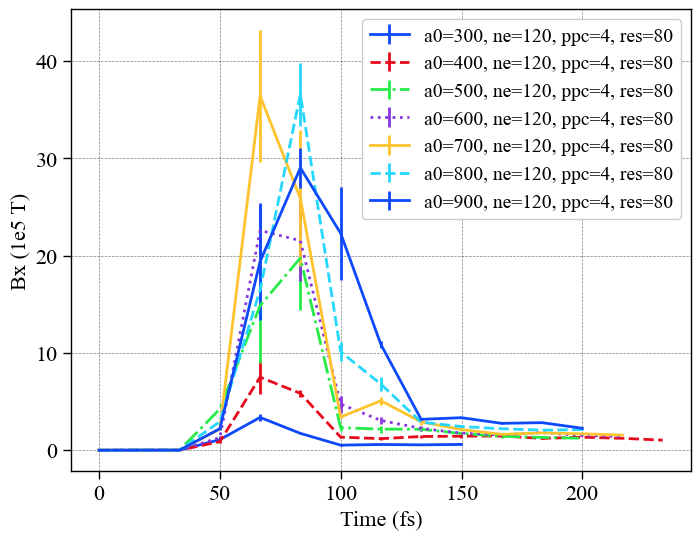

In [35]:
plt.errorbar(time_fs_a0400_ne120_ppc4_res80[:Bx_avg_arr_a0300_ne120_ppc4_res80.size], Bx_avg_arr_a0300_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0300_ne120_ppc4_res80),
             label="a0=300, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0400_ne120_ppc4_res80, Bx_avg_arr_a0400_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0400_ne120_ppc4_res80),
             label="a0=400, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0500_ne120_ppc4_res80, Bx_avg_arr_a0500_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0500_ne120_ppc4_res80),
             label="a0=500, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0600_ne120_ppc4_res80, Bx_avg_arr_a0600_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0600_ne120_ppc4_res80),
             label="a0=600, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0700_ne120_ppc4_res80, Bx_avg_arr_a0700_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0700_ne120_ppc4_res80),
             label="a0=700, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0800_ne120_ppc4_res80, Bx_avg_arr_a0800_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0800_ne120_ppc4_res80),
             label="a0=800, ne=120, ppc=4, res=80")
plt.errorbar(time_fs_a0900_ne120_ppc4_res80, Bx_avg_arr_a0900_ne120_ppc4_res80, 
             yerr=np.abs(Bx_err_arr_a0900_ne120_ppc4_res80),
             label="a0=900, ne=120, ppc=4, res=80")

plt.xlabel("Time (fs)")
plt.ylabel("Bx (1e5 T)")
plt.legend(fontsize=14)
# plt.xlim(100, time_fs[-1])
# plt.ylim(0,8)
# plt.show()
plt.savefig(wkdir[0]+"Bx_evolution.png", dpi=600)

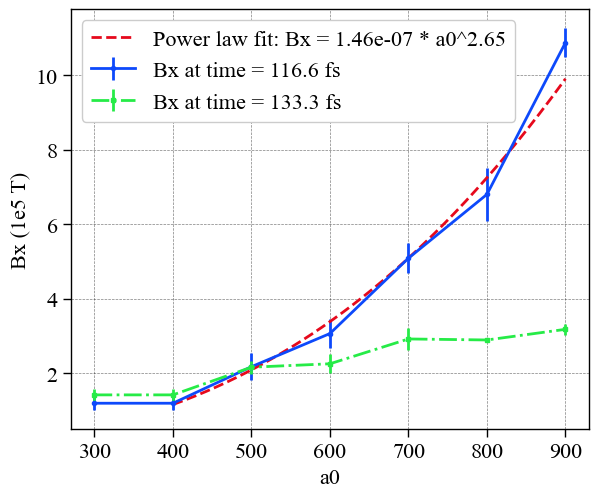

In [53]:
ts = 7

a0 = [300, 400, 500, 600, 700, 800, 900]
Bx_ave_at_ts7 = [Bx_avg_arr_a0400_ne120_ppc4_res80[ts], Bx_avg_arr_a0400_ne120_ppc4_res80[ts], Bx_avg_arr_a0500_ne120_ppc4_res80[ts],
                Bx_avg_arr_a0600_ne120_ppc4_res80[ts], Bx_avg_arr_a0700_ne120_ppc4_res80[ts], Bx_avg_arr_a0800_ne120_ppc4_res80[ts], 
                Bx_avg_arr_a0900_ne120_ppc4_res80[ts]]
Bx_err_at_ts7 = [Bx_err_arr_a0400_ne120_ppc4_res80[ts], Bx_err_arr_a0400_ne120_ppc4_res80[ts], Bx_err_arr_a0500_ne120_ppc4_res80[ts],
                Bx_err_arr_a0600_ne120_ppc4_res80[ts], Bx_err_arr_a0700_ne120_ppc4_res80[ts], Bx_err_arr_a0800_ne120_ppc4_res80[ts], 
                Bx_err_arr_a0900_ne120_ppc4_res80[ts]]  

ts = 8

Bx_ave_at_ts8 = [Bx_avg_arr_a0400_ne120_ppc4_res80[ts], Bx_avg_arr_a0400_ne120_ppc4_res80[ts], Bx_avg_arr_a0500_ne120_ppc4_res80[ts],
                Bx_avg_arr_a0600_ne120_ppc4_res80[ts], Bx_avg_arr_a0700_ne120_ppc4_res80[ts], Bx_avg_arr_a0800_ne120_ppc4_res80[ts], 
                Bx_avg_arr_a0900_ne120_ppc4_res80[ts]]
Bx_err_at_ts8 = [Bx_err_arr_a0400_ne120_ppc4_res80[ts], Bx_err_arr_a0400_ne120_ppc4_res80[ts], Bx_err_arr_a0500_ne120_ppc4_res80[ts],
                Bx_err_arr_a0600_ne120_ppc4_res80[ts], Bx_err_arr_a0700_ne120_ppc4_res80[ts], Bx_err_arr_a0800_ne120_ppc4_res80[ts], 
                Bx_err_arr_a0900_ne120_ppc4_res80[ts]]  

plt.figure(figsize=(6, 5))
plt.errorbar(a0, Bx_ave_at_ts7, yerr=Bx_err_at_ts7, marker="o", label="Bx at time = {:.1f} fs".format(time_fs_a0400_ne120_ppc4_res80[7]))

# ---- Fit a power law: Bx = C * a0^p ----
log_a0 = np.log(a0[1:])
log_Bx = np.log(Bx_ave_at_ts7[1:])
p, logC = np.polyfit(log_a0, log_Bx, 1)
C = np.exp(logC)

# Smooth curve for the fitted relation
a0_fit = np.linspace(400, 900, 500)
Bx_fit = C * a0_fit**p

plt.plot(a0_fit, Bx_fit, label="Power law fit: Bx = {:.2e} * a0^{:.2f}".format(C, p))

plt.errorbar(a0, Bx_ave_at_ts8, yerr=Bx_err_at_ts8, marker="s", label="Bx at time = {:.1f} fs".format(time_fs_a0400_ne120_ppc4_res80[8]))
plt.xlabel("a0")
plt.ylabel("Bx (1e5 T)")
plt.legend()
plt.tight_layout()
plt.savefig(wkdir[0]+"Bx_vs_a0.png", dpi=600)

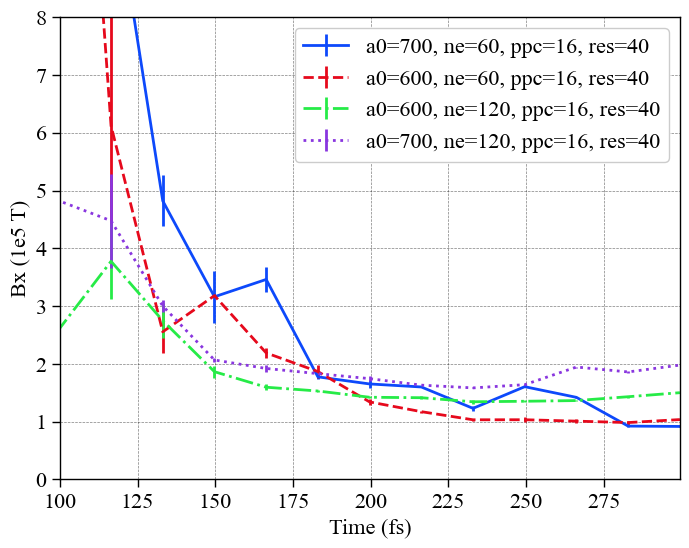

In [ ]:
plt.errorbar(time_fs, Bx_avg_arr_a0700_ne60_ppc16_res40, 
             yerr=np.abs(Bx_err_arr_a0700_ne60_ppc16_res40),
             label="a0=700, ne=60, ppc=16, res=40")
plt.errorbar(time_fs, Bx_avg_arr_a0600_ne60_ppc16_res40, 
             yerr=np.abs(Bx_err_arr_a0600_ne60_ppc16_res40),
             label="a0=600, ne=60, ppc=16, res=40")
plt.errorbar(time_fs, Bx_avg_arr_a0600_ne120_ppc16_res40, 
             yerr=np.abs(Bx_err_arr_a0600_ne120_ppc16_res40),
             label="a0=600, ne=120, ppc=16, res=40")
plt.errorbar(time_fs, Bx_avg_arr_a0700_ne120_ppc16_res40, 
             yerr=np.abs(Bx_err_arr_a0700_ne120_ppc16_res40),
             label="a0=700, ne=120, ppc=16, res=40")
plt.xlabel("Time (fs)")
plt.ylabel("Bx (1e5 T)")
plt.legend()
plt.xlim(100, time_fs[-1])
plt.ylim(0,8)
plt.show()



In [22]:
np.savez(wkdir[0]+"Bx_data.npz",
         time=time_fs,
         err=Bx_err_arr,
         avg=Bx_avg_arr)

time =  133.28130964242507  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_49082/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  1.554215816784083  GG
max Bx_filt =  1.2566893299861215  GG
error bar =  0.14876324339898073  GG
ave Bx =  1.4054525733851022  GG


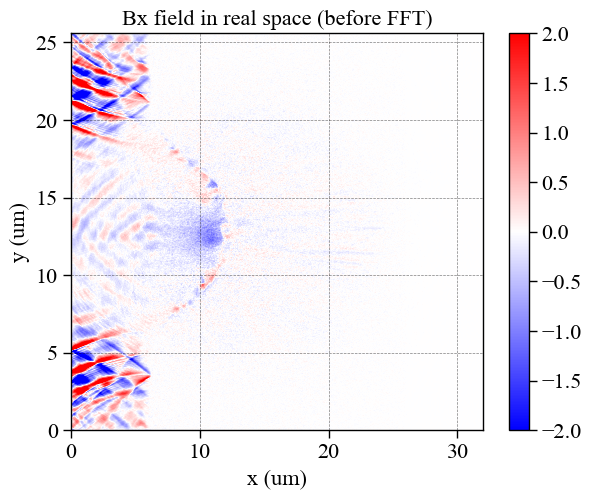

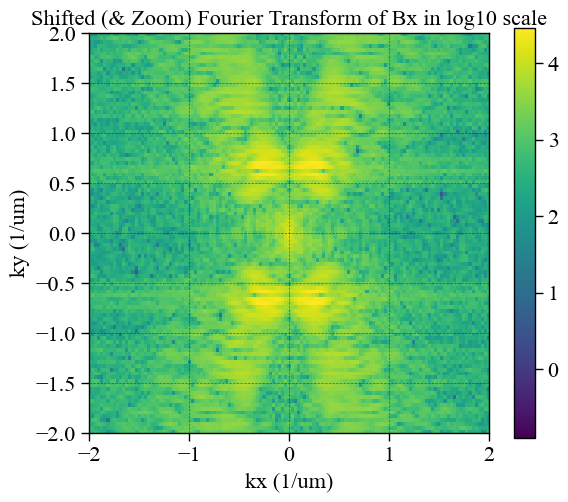

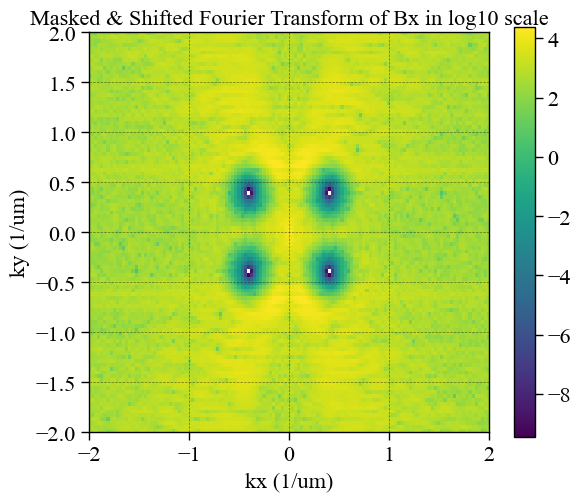

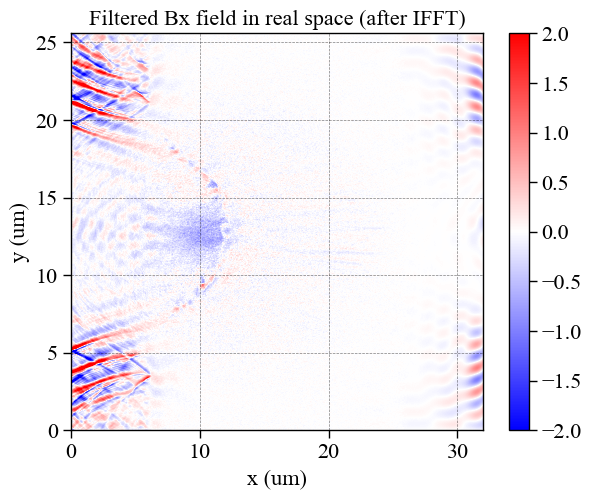

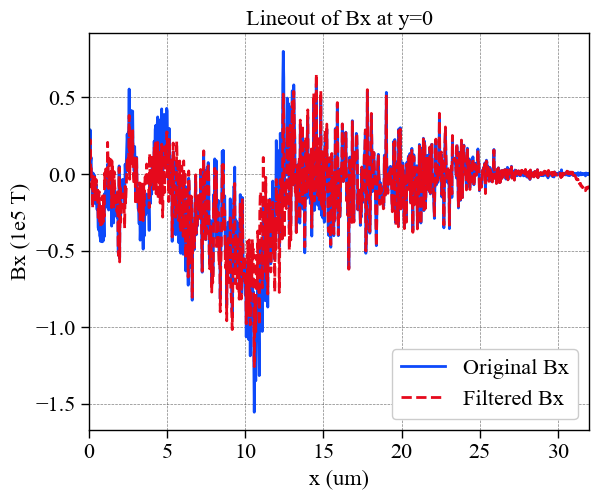

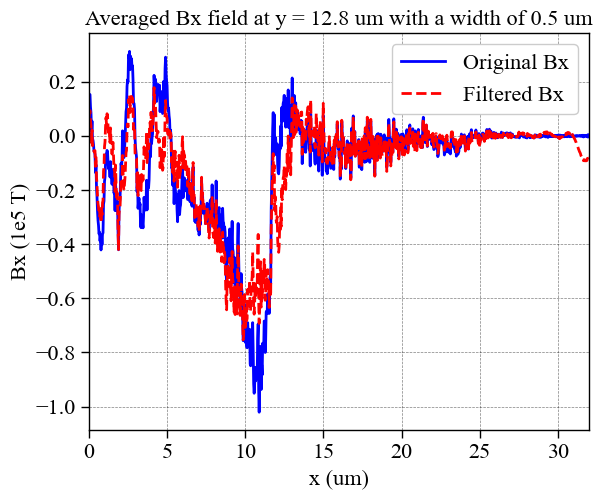

In [14]:
post_process_Bx_field(
    S1, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=8, vmin0=-2, vmax0=2
)

time =  133.28130964242507  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_49082/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  2.63583266241324  GG
max Bx_filt =  2.578158165836132  GG
error bar =  0.02883724828855394  GG
ave Bx =  2.606995414124686  GG


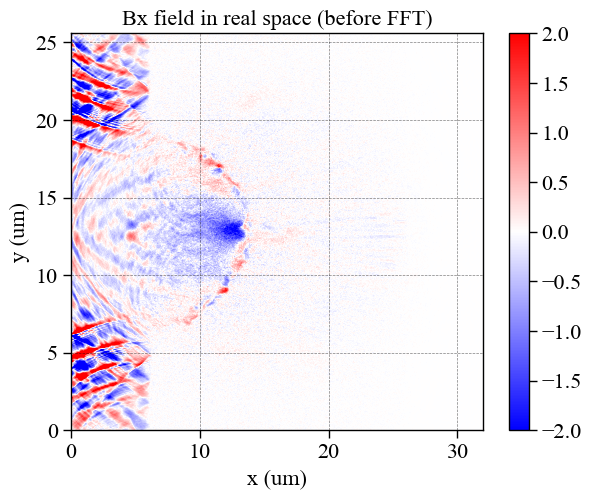

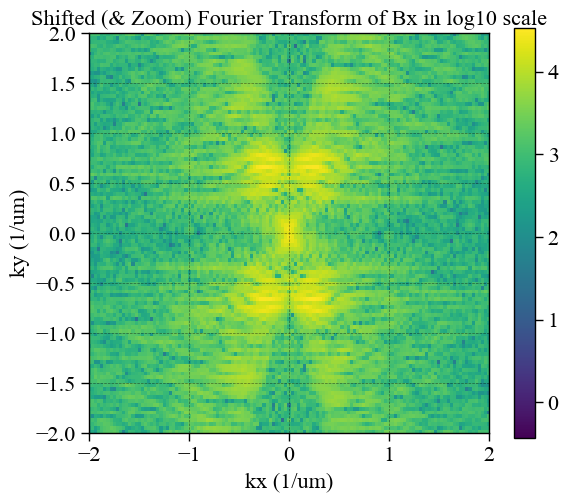

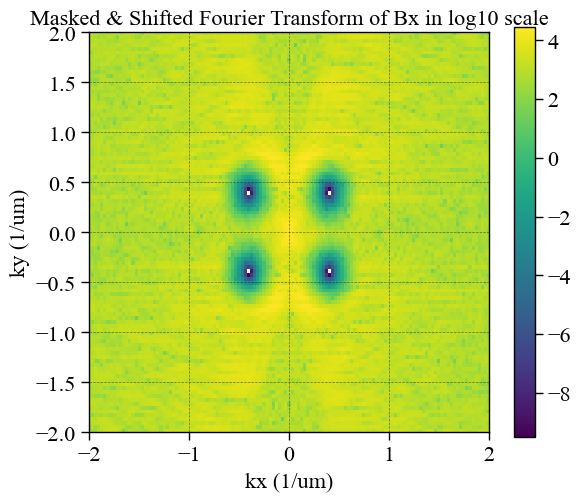

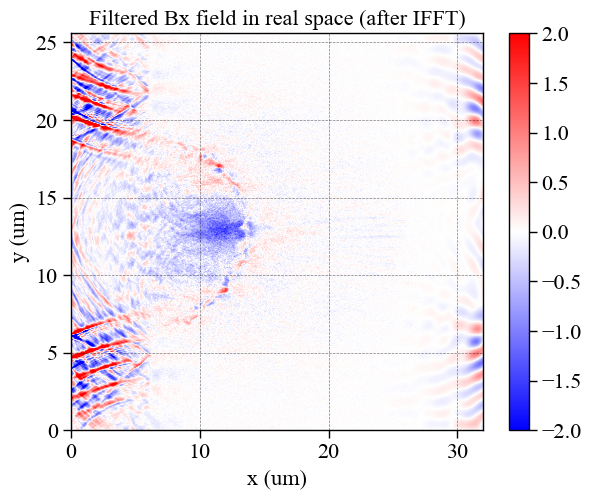

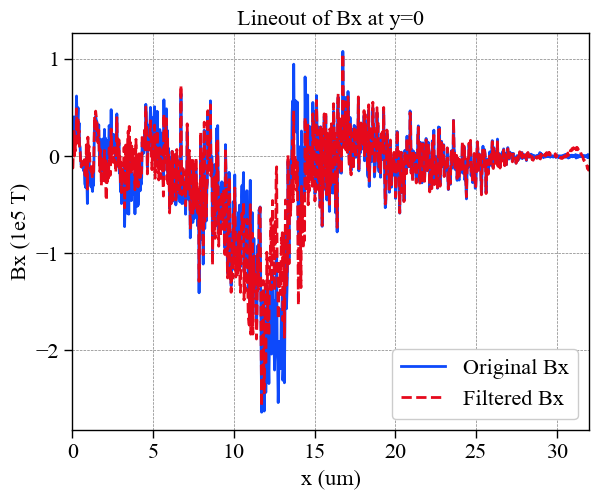

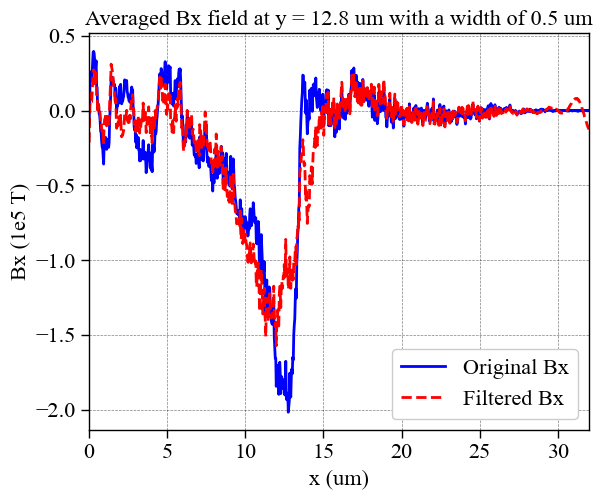

In [15]:
post_process_Bx_field(
    S2, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=8, vmin0=-2, vmax0=2
)

time =  133.28130964242507  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_49082/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  3.1017587554067414  GG
max Bx_filt =  2.524202349374853  GG
error bar =  0.28877820301594426  GG
ave Bx =  2.812980552390797  GG


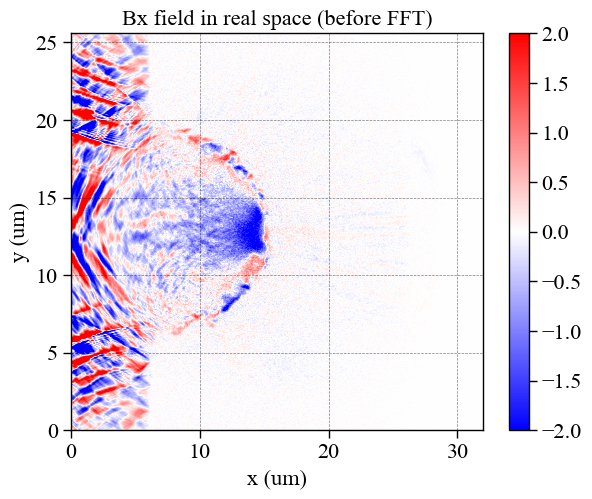

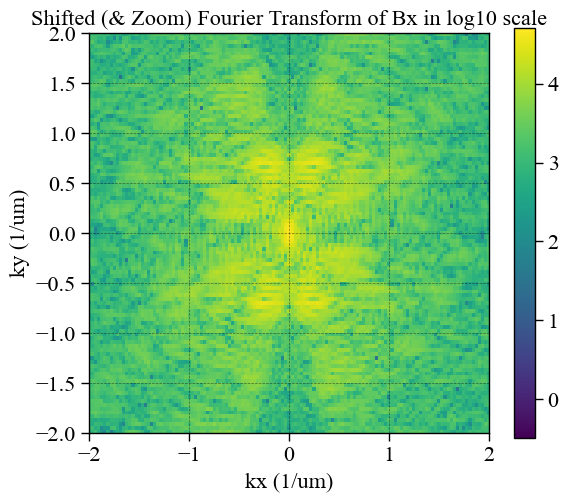

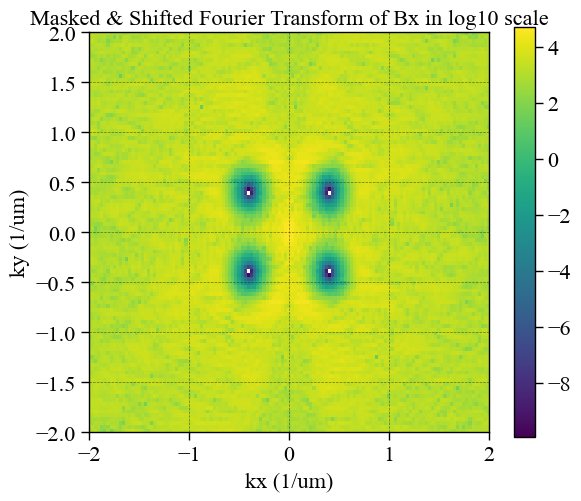

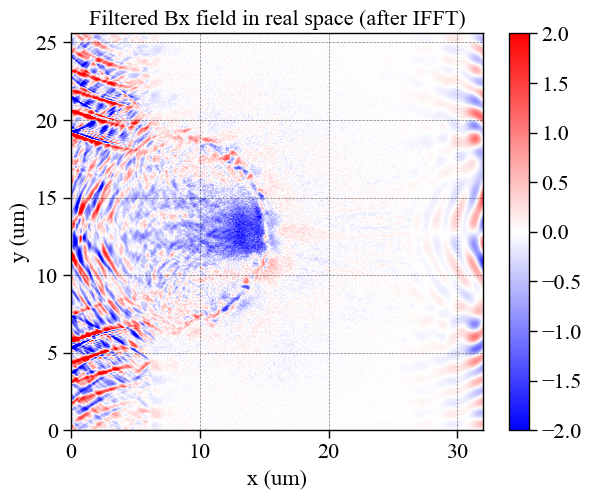

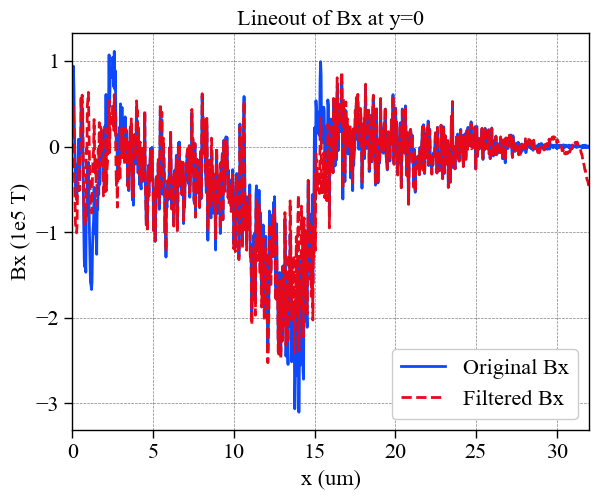

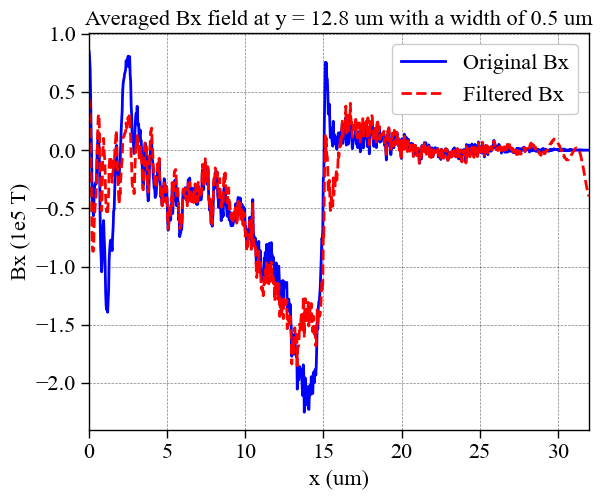

In [16]:
post_process_Bx_field(
    S3, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=8, vmin0=-2, vmax0=2
)